# Predicting Galaxy Redshift with Decision Trees and Ensemble Methods 

This notebook was inspired by [Predicting galaxy redshift via regression on 3D-HST photometry](https://spacetelescope.github.io/hellouniverse/notebooks/hello-universe/Regressing_3D-HST_galaxy_redshift_with_decision_trees/Regressing_3D-HST_galaxy_redshift_with_decision_trees.html).

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn import tree
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
import joblib
import pandas as pd
from sklearn.model_selection import GridSearchCV, KFold
import plotly.colors as colors
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import tarfile
from astropy.utils.data import download_file
from astropy.table import Table
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

%matplotlib inline

## Download and Examine Dataset

Let's get started by downloading out data from astropy and converting it into a pandas dataframe.

In [2]:
# First, download the 3D-HST catalog from the MAST archive. This dataset is described in Skelton et. al 2014.
file_url = 'https://archive.stsci.edu/missions/hlsp/3d-hst/RELEASE_V4.0/Photometry/3dhst_master.phot.v4.1.tar'
tarfile.open(download_file(file_url, cache=True), "r:").extract('3dhst_master.phot.v4.1/3dhst_master.phot.v4.1.cat', '.')
# Read the combined photmetric catalog into a dataframe via astropy
tab = Table.read('3dhst_master.phot.v4.1/3dhst_master.phot.v4.1.cat', format='ascii').to_pandas()

The data we use for the tutrial is from the [3D-HST survey](https://archive.stsci.edu/prepds/3d-hst/).The dataset contains Hubble Space Telescope (HST) data.The dataset contains standard information such as target id, field name, coordinates, fluxes, errors, and various photometric flags. In addition, there are derived properties such as photometric redshift (z_peak), spectroscopic redshift (z_spec), mass (lmass) and dust extinction in the V band (Av). Let's examine the contents.

In [3]:
tab

,id,field,ra,dec,x,y,z_spec,z_peak,faper_F140W,eaper_F140W,...,flags,f140w_flag,star_flag,use_phot,near_star,nexp_f125w,nexp_f140w,nexp_f160w,lmass,Av
0,1.0,AEGIS,215.222382,53.004185,9590.50,3057.30,-1.0000,0.0100,-82.0410,-82.041000,...,0,0,1,0,0,2,0,3,7.51,1.1
1,2.0,AEGIS,215.096588,52.918053,16473.20,3150.20,-1.0000,0.0100,3.5078,0.074233,...,3,0,0,0,0,4,4,4,5.62,0.1
2,3.0,AEGIS,215.161469,52.959461,13060.10,2982.30,-1.0000,0.2062,-1.9043,-1.904300,...,1,0,0,1,0,2,0,2,9.00,1.1
3,4.0,AEGIS,215.305298,53.052921,5422.80,2692.10,-1.0000,0.0355,-72.3250,-72.325000,...,0,0,0,0,0,1,0,1,4.78,0.4
4,5.0,AEGIS,215.041840,52.871273,19894.60,2834.40,-1.0000,0.3427,1890.5000,0.133300,...,0,1,2,0,1,0,3,0,11.57,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207962,44098.0,UDS,34.363106,-5.122067,14578.84,11076.42,-1.0000,0.1852,188.8200,0.170750,...,0,1,2,0,0,0,3,0,10.21,0.2
207963,44099.0,UDS,34.333569,-5.123219,16343.92,11007.12,-1.0000,0.6716,1.7193,0.129080,...,0,1,2,0,0,0,3,0,8.49,0.7
207964,44100.0,UDS,34.363682,-5.123123,14544.39,11013.01,1.4196,2.7489,1.3829,0.113830,...,0,1,2,0,0,0,4,0,9.08,1.4
207965,44101.0,UDS,34.556389,-5.123040,3028.23,11017.04,-1.0000,1.1716,-99.0000,-99.000000,...,1,0,0,0,0,1,0,2,10.55,1.0


In [4]:
tab.columns

Index(['id', 'field', 'ra', 'dec', 'x', 'y', 'z_spec', 'z_peak', 'faper_F140W',
       'eaper_F140W', 'faper_F160W', 'eaper_F160W', 'f_F606W', 'e_F606W',
       'f_F814W', 'e_F814W', 'f_F125W', 'e_F125W', 'f_F140W', 'e_F140W',
       'f_F160W', 'e_F160W', 'tot_cor', 'kron_radius', 'a_image', 'b_image',
       'flux_radius', 'fwhm_image', 'flags', 'f140w_flag', 'star_flag',
       'use_phot', 'near_star', 'nexp_f125w', 'nexp_f140w', 'nexp_f160w',
       'lmass', 'Av'],
      dtype='object')

### 0.1 Perform Data Cleaning Steps

We will use the same code to clean and transform our data as we did in the linear regression notebooks yesterday.  The comments in the code below highlights the decisions we made.

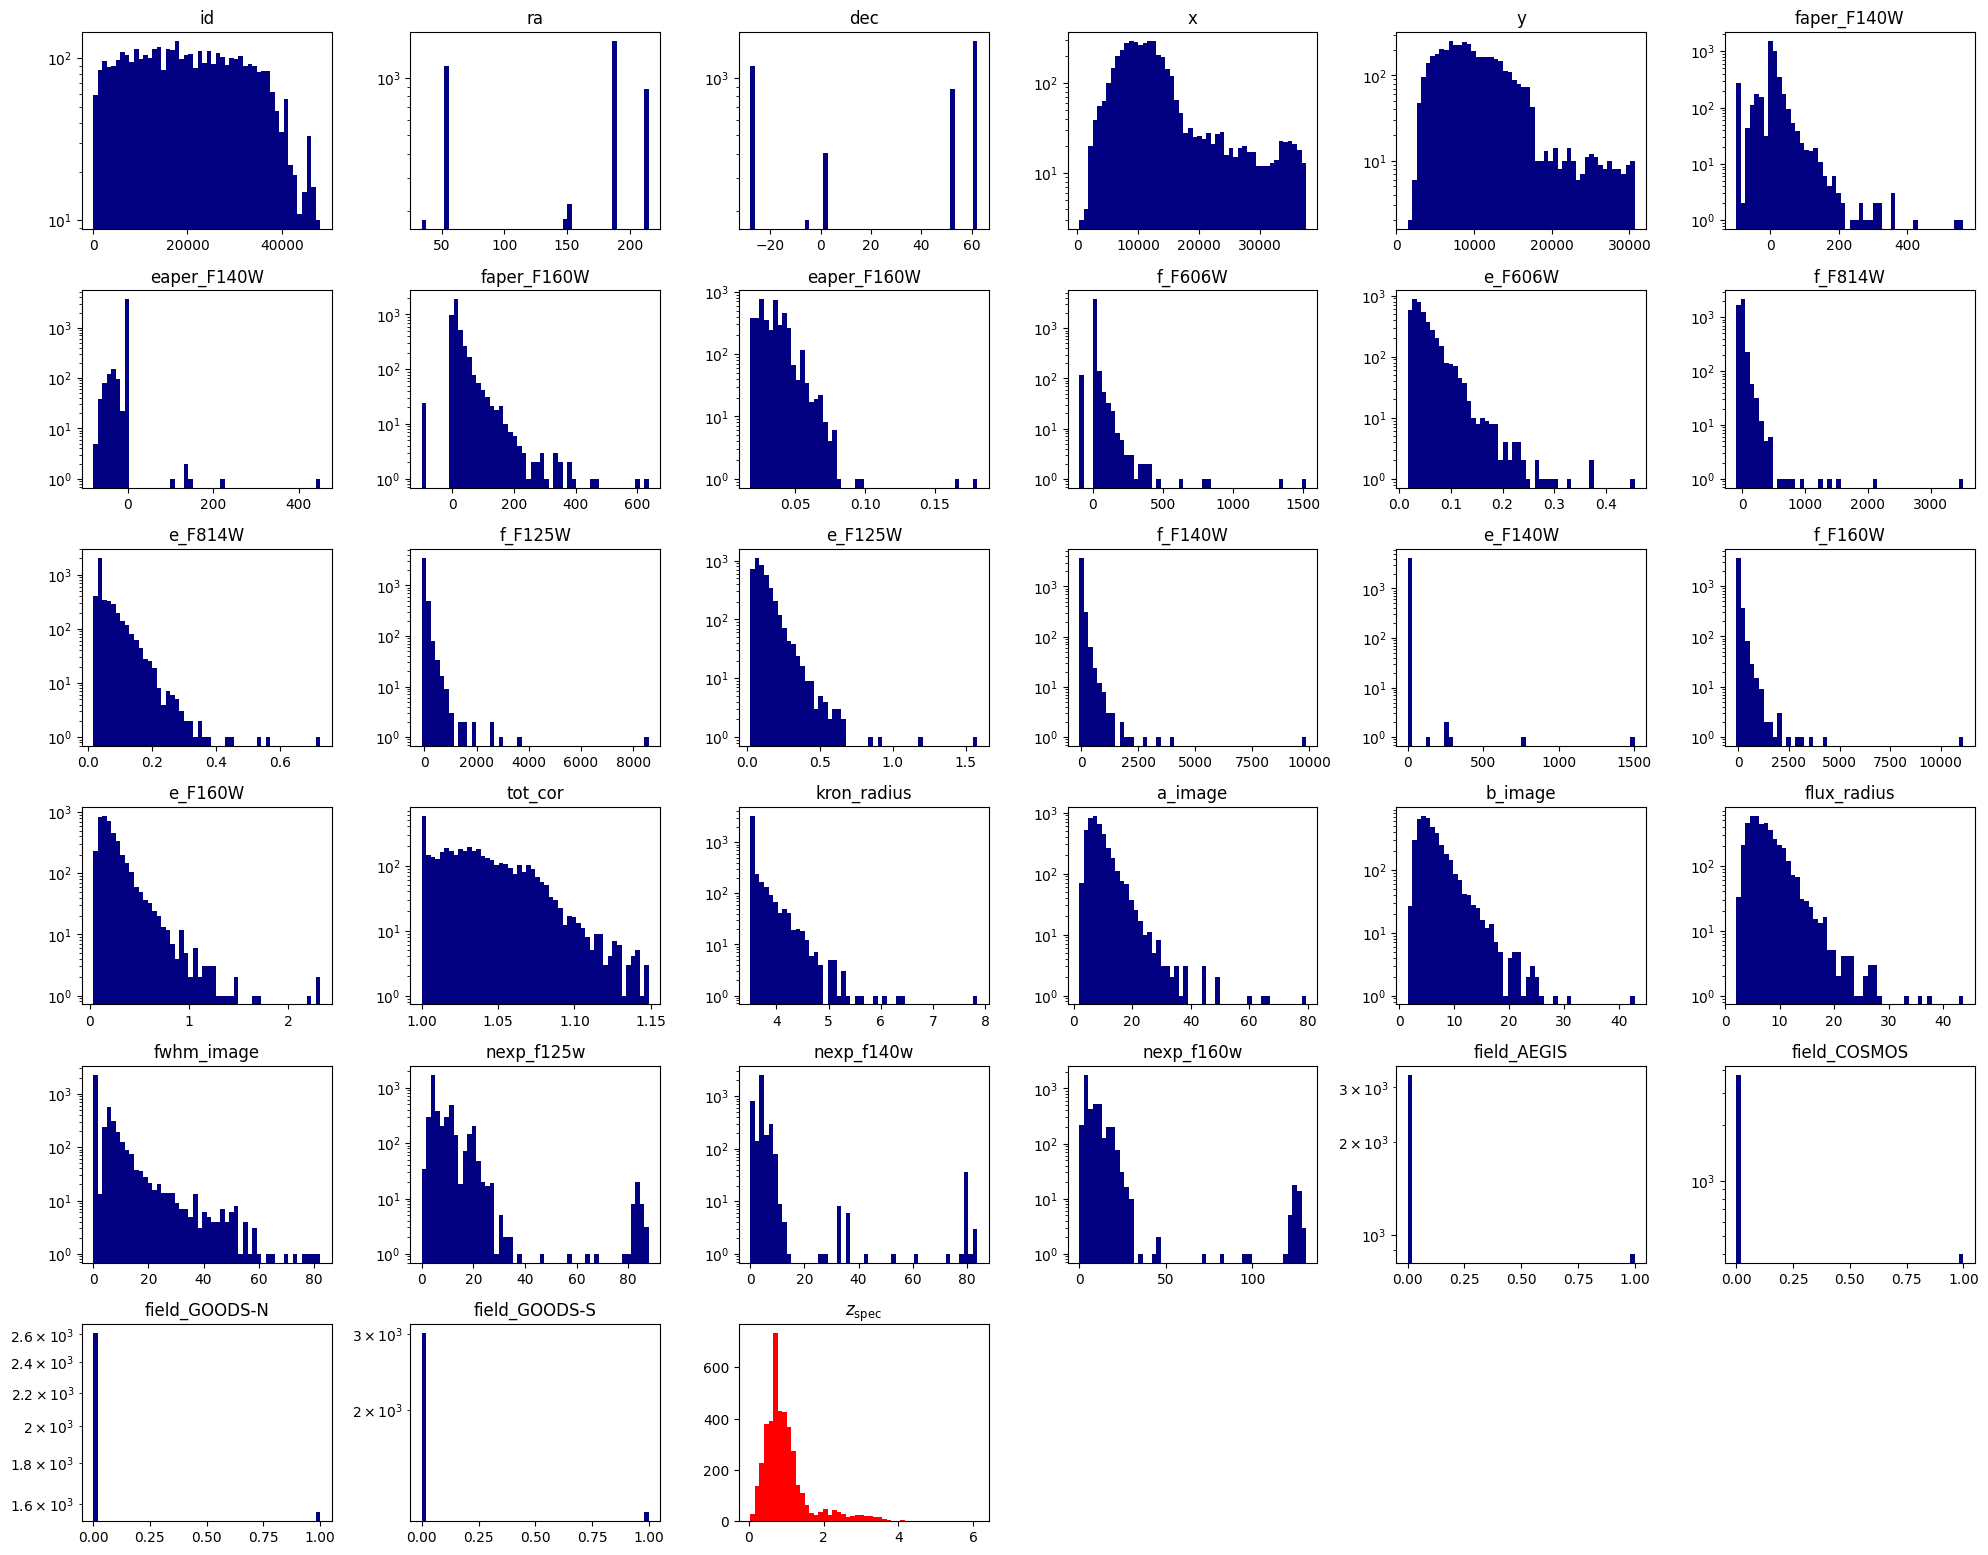

In [5]:
# filter data points based on lmass values with full coverage of z_spec
tab = tab[tab.lmass > 9].copy()

# define target
target = 'z_spec'

# Next, we will remove sources which have no constraints for our target variable:
tab = tab[(tab[target] > 0)] 

# Next, we will encode the ‘field” variable, using one hot encoder
tab = pd.get_dummies(tab, columns=['field'],dtype=float)

# Create list of features wie will use for our model
features = [col for col in tab.columns if (col != target)]

# Remove unneeded features 
# The ‘Av’, ‘lmass’ and ‘z_peak’ values were all computed via FAST photometric fit, and so we will exclude them as well. 
# In addition, we will exclude the categorical flag variables (‘flags’, ‘f140w_flag’, ‘star_flag’, ‘use_phot’, ‘near_star’).
# Finally, we will remove field and field_UDS as they are needed after pd.get_dummies
features = [col for col in features if (col != 'Av') and (col != 'lmass') and (col != 'z_peak') 
            and (col != 'flags') and (col != 'f140w_flag') and (col != 'star_flag') 
            and (col != 'use_phot') and (col != 'near_star') and (col != 'field') 
            and (col != 'field_UDS')]

# Finally we will impute missing values of photometric errors (set to -99. in the table) by assigning them the median of the distribution:
errors = [col for col in features if (col[:1] == 'e') and (col[-1:] == 'W')]
for error in errors:
    tab[error] = np.where(tab[error] < -90, tab[error].median(), tab[error])

# plot distribution of remaining features
fig = plt.figure(0, [20, 18])

for k, feat in enumerate(features):
    ax = fig.add_subplot(7, 6, k+1)
    ax.hist(tab[feat], bins=50, log=True, color='navy')
    ax.set_title(feat)

ax = fig.add_subplot(7, 6, len(features)+1)
ax.hist(tab[target], bins=50, color='red')
ax.set_title(r'$z_{\rm spec}$')

plt.tight_layout()
plt.show()

In [6]:
tab.columns

Index(['id', 'ra', 'dec', 'x', 'y', 'z_spec', 'z_peak', 'faper_F140W',
       'eaper_F140W', 'faper_F160W', 'eaper_F160W', 'f_F606W', 'e_F606W',
       'f_F814W', 'e_F814W', 'f_F125W', 'e_F125W', 'f_F140W', 'e_F140W',
       'f_F160W', 'e_F160W', 'tot_cor', 'kron_radius', 'a_image', 'b_image',
       'flux_radius', 'fwhm_image', 'flags', 'f140w_flag', 'star_flag',
       'use_phot', 'near_star', 'nexp_f125w', 'nexp_f140w', 'nexp_f160w',
       'lmass', 'Av', 'field_AEGIS', 'field_COSMOS', 'field_GOODS-N',
       'field_GOODS-S', 'field_UDS'],
      dtype='object')

### 0.2 Divide the Data into Train, Test and Validation sets

In [7]:
# Divide the data into train, test and validation sets
X = tab[features].values
y = tab[target].values
indices = np.arange(len(y))

# first reserve 70% of the data for training, 30% for validation
X_train, X_validate, y_train, y_validate, indices_train, indices_validate = train_test_split(X, y, indices, test_size=0.3, random_state=42)

# second, split the validation set in half to obtain validation and test sets. 
X_validate, X_test, y_validate, y_test, indices_validate, indices_test = train_test_split(X_validate, y_validate, indices_validate, test_size=0.5, random_state=42)

### DecisionTreeRegressor

Decision trees can also be applied to regression problems, using the DecisionTreeRegressor class.

As in the classification setting, the fit method will take as argument arrays X and y, only that in this case y is expected to have floating point values instead of integer values.  Let's see what performance we can get with default hyperpameters values.

MSE of Decision Tree model with default hyperparameters = 0.1951


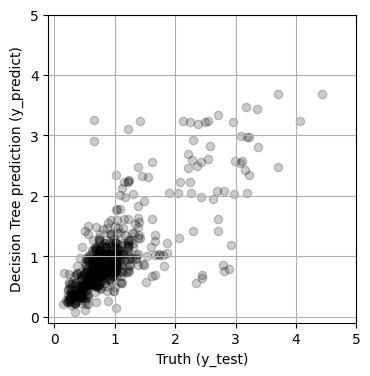

In [8]:
# Initialize the model
dtree = DecisionTreeRegressor()

# Fit the model parameters using the training dataset
dtree.fit(X_train, y_train)

y_predict = dtree.predict(X_test)
print(f'MSE of Decision Tree model with default hyperparameters = {mean_squared_error(y_test, y_predict):.4f}')

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(y_test, y_predict, alpha=0.2, color='black')
ax.set_aspect('equal')
ax.set_xlim(-0.1, 5)
ax.set_ylim(-0.1, 5)
ax.grid()
ax.set_xlabel('Truth (y_test)')
ax.set_ylabel('Decision Tree prediction (y_predict)')
plt.show()

Let's try using `sklearn`s grid search tools.  This time we will try `RandomizedSearchCV`. When using `RandomizedSearchCV`, we will define a probability distribution (via scipy.stats library) for each feature we want to explore in our grid search. If a numpy array is provided, a value will be sampled uniformly from the array. 

In [9]:
import scipy.stats as stats
hyperparameter_distributions = {
    'max_depth': stats.randint(1, 20),                       # defining a random integer probabl dist
    'min_samples_split': np.arange(5, 105, 10).astype(int),  # if array of values provided, a value will be sampled uniformly
    'min_samples_leaf': np.arange(5, 105, 10).astype(int)
}

In [10]:
# import object needed from skelarn
from sklearn.model_selection import RandomizedSearchCV

# instantiate DT mode
dtree = DecisionTreeRegressor()

# instantiate RandomizedSearchCV
random_search = RandomizedSearchCV(
    dtree, 
    param_distributions=hyperparameter_distributions,
    n_iter=100     # number of samples considered from definited probability distributions
) 

# note I did not specify cv here; default value is 5
random_search.fit(X_train, y_train);

In [11]:
# printing best hyperparameter combo found
print(random_search.best_params_)

# I can pull out best performing model with random_search.best_estimator_ attribute

{'max_depth': 7, 'min_samples_leaf': np.int64(15), 'min_samples_split': np.int64(15)}


Decision Tree model with best performance from hyperparameter search = 0.1493


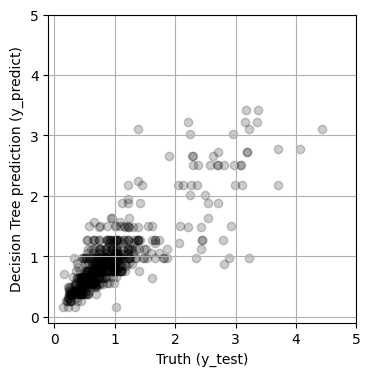

In [12]:
y_predict = random_search.best_estimator_.predict(X_test)
print(f'Decision Tree model with best performance from hyperparameter search = {mean_squared_error(y_test, y_predict):.4f}')
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(y_test, y_predict, alpha=0.2, color='black')
ax.set_aspect('equal')
ax.set_xlim(-0.1, 5)
ax.set_ylim(-0.1, 5)
ax.grid()
ax.set_xlabel('Truth (y_test)')
ax.set_ylabel('Decision Tree prediction (y_predict)');

In [13]:
# we will create these plots later on in this notebook, so I will put the code into a function 
def plot_truth_v_prediction(ax,y_test,y_predict,ylabel='prediction (y_predict)'):
    ax.scatter(y_test, y_predict, alpha=0.2, color='black')
    ax.set_aspect('equal')
    ax.set_xlim(-0.1, 5)
    ax.set_ylim(-0.1, 5)
    ax.grid()
    ax.set_xlabel('Truth (y_test)')
    ax.set_ylabel(ylabel)

Ok, great we now have improved our performance compared to where we got to using linear regression yesterday.  Next let's see if Ensemble methods can help us even more.

# Random Forest 

In [14]:
# use parameters from my best performing DT model 
params=random_search.best_params_

# Initialize the model
rf = RandomForestRegressor(**params)

rf.fit(X_train, y_train);

First Random Forest model performance MSE = 0.1281


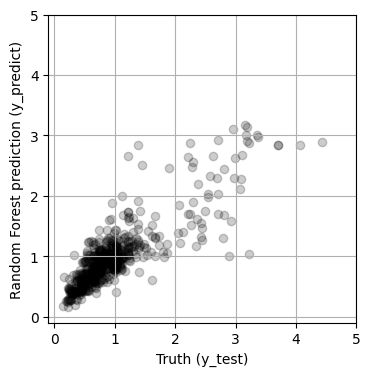

In [15]:
y_predict = rf.predict(X_test)
print(f'First Random Forest model performance MSE = {mean_squared_error(y_test, y_predict):.4f}')

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
plot_truth_v_prediction(ax,y_test,y_predict,ylabel='Random Forest prediction (y_predict)');

### Exercise

We have pretty good performance already! One new but important parameter introduced when moving from DT to RF is the number of trees.  Try varying the number of trees and see how the performance changes. Use the same params used in the previous RF model

Text(0, 0.5, 'MSE')

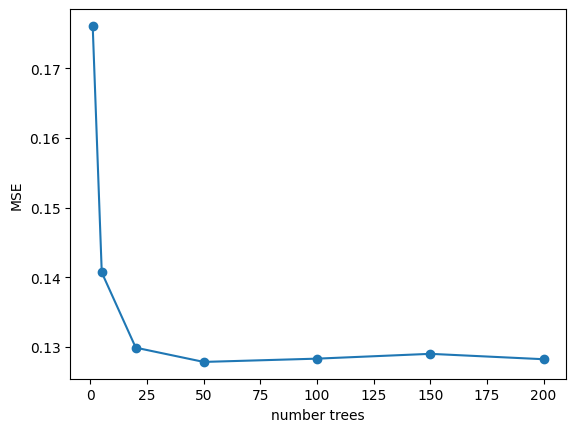

In [16]:
# use the same parameters as the Decision Tree
mse=[]
nest= [1,5,20,50,100,150,200]
for x in nest:
    params=random_search.best_params_
    params['n_estimators']=x
    
    # Initialize the model
    rf = RandomForestRegressor(**params)
    
    rf.fit(X_train, y_train)
    y_predict = rf.predict(X_test)
    mse.append(mean_squared_error(y_test, y_predict))

fig,ax=plt.subplots()
ax.plot(nest,mse)
ax.scatter(nest,mse)
ax.set_xlabel('number trees')
ax.set_ylabel('MSE')

## Random Forest Hyperparamter Optimization

In [17]:
model = RandomForestRegressor(random_state=0, n_jobs=-1)

param_grid = {"max_depth": np.arange(1, 20, 2).astype(int),  # defining a random integer probabl dist
    'min_samples_split': np.arange(5, 105, 10).astype(int),               # if array of values provided, a value will be sampled uniformly
    'min_samples_leaf': np.arange(5, 105, 10).astype(int)}
# We use K-Fold cross-validator.
# This give us more control over splits in cross validation
cv = KFold(n_splits=4, shuffle=True, random_state=0)


grid_search_rf = RandomizedSearchCV(
    estimator=model,
    param_distributions=hyperparameter_distributions,
    n_iter=100,
    return_train_score=True,      # returns data on training times and detailed analysis of evaluation metrics
    cv=cv,
    scoring='neg_mean_squared_error'
).fit(X_train, y_train)

In [18]:
y_predict = grid_search_rf.best_estimator_.predict(X_test)
print(f'First Random Forest model performance MSE = {mean_squared_error(y_test, y_predict):.4f}')

First Random Forest model performance MSE = 0.1259


In [19]:
cv_result = pd.DataFrame(grid_search_rf.cv_results_)
cv_result.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,...,split3_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,mean_train_score,std_train_score
0,0.251666,0.013739,0.045255,0.002757,15,95,85,"{'max_depth': 15, 'min_samples_leaf': 95, 'min...",-0.172223,-0.189763,...,-0.166863,-0.192605,0.029512,81,-0.181692,-0.186733,-0.163204,-0.188645,-0.180069,0.010063
1,0.228377,0.008467,0.042103,0.000865,1,85,25,"{'max_depth': 1, 'min_samples_leaf': 85, 'min_...",-0.241693,-0.264390,...,-0.229890,-0.261053,0.029931,95,-0.256434,-0.250714,-0.241618,-0.258711,-0.251869,0.006597
2,0.295451,0.007902,0.046408,0.002192,10,45,55,"{'max_depth': 10, 'min_samples_leaf': 45, 'min...",-0.160673,-0.163898,...,-0.139836,-0.171181,0.029835,55,-0.148530,-0.152892,-0.135320,-0.158883,-0.148906,0.008662
3,0.240840,0.010518,0.050359,0.003249,2,85,75,"{'max_depth': 2, 'min_samples_leaf': 85, 'min_...",-0.194615,-0.207499,...,-0.183557,-0.212521,0.031135,94,-0.209331,-0.201013,-0.192452,-0.211478,-0.203569,0.007514
4,0.354771,0.015800,0.048846,0.005599,12,15,85,"{'max_depth': 12, 'min_samples_leaf': 15, 'min...",-0.156061,-0.152503,...,-0.129129,-0.160524,0.027364,27,-0.129728,-0.134446,-0.117442,-0.142067,-0.130921,0.008941


Text(0, 0.5, 'mean test score (MSE)')

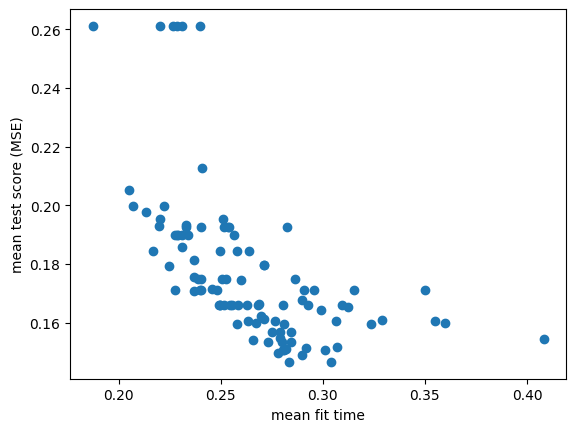

In [20]:
fig,ax=plt.subplots()
ax.scatter(cv_result.mean_fit_time, -1*cv_result.mean_test_score)
ax.set_xlabel('mean fit time')
ax.set_ylabel('mean test score (MSE)')

### Random Forest: Feature importance based on mean decrease in impurity (Gini Importance)

Tutorial is based on https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html.


Feature importances are provided by the fitted attribute feature_importances_ and they are computed as the mean and standard deviation of accumulation of the impurity decrease within each tree.

In [21]:
importances = grid_search_rf.best_estimator_.feature_importances_
std = np.std([tree.feature_importances_ for tree in grid_search_rf.best_estimator_.estimators_], axis=0)

Let’s plot the impurity-based importance.

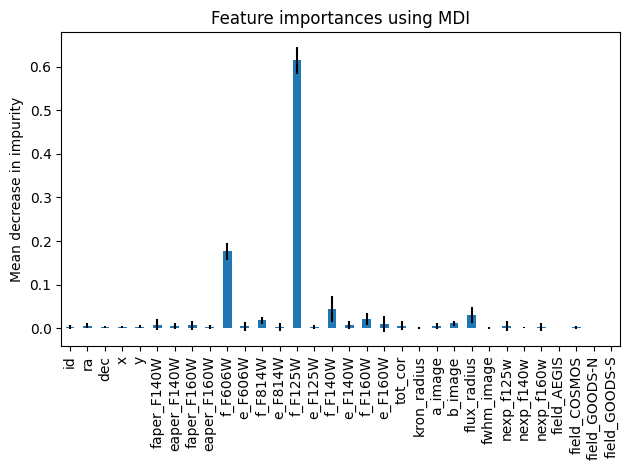

In [22]:
forest_importances = pd.Series(grid_search_rf.best_estimator_.feature_importances_, index=features)
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

The most “important” features in this model are the F125W and F606W fluxes. Parameters such as id, ra, dec, x, and y understandably have very little influence on the predictions.

## 3. Gradient Boosting: Xgboost

In [23]:
# instantiate and fit model 
model = xgb.XGBRegressor().fit(X_train, y_train)

# We evaluate a model and make predictions as we would do in scikit-learn.
# make predictions
predictions = model.predict(X_test)
print("Mean Squared Error : " + str(mean_squared_error(predictions, y_test)))

Mean Squared Error : 0.1311398930213986


### Model Tuning

XGBoost has a few parameters that can dramatically affect your model's accuracy and training speed. In this tutorial we will run parameter scan on n_estimators and early_stopping_rounds.

N_estimators is the number of gradient boosted trees (Equivalent to number of boosting rounds).

Early_stopping_rounds offers a way to automatically find the ideal value. Early stopping causes the model to stop iterating when the validation score stops improving, even if we aren't at the hard stop for n_estimators.

Here we set a high value for n_estimators and then use early_stopping_rounds to find the optimal time to stop iterating.

In [24]:
model = xgb.XGBRegressor().fit(X_train, y_train)
# We evaluate a model and make predictions as we would do in scikit-learn.
# make predictions
predictions = model.predict(X_test)
print("Mean Squared Error : " + str(mean_squared_error(predictions, y_test)))

Mean Squared Error : 0.1311398930213986


In [25]:
model = xgb.XGBRegressor(n_estimators=100, early_stopping_rounds=5).fit(
                X_train, y_train, 
                eval_set=[(X_test, y_test)], verbose=True);

[0]	validation_0-rmse:0.54179
[1]	validation_0-rmse:0.47178
[2]	validation_0-rmse:0.42935
[3]	validation_0-rmse:0.40160
[4]	validation_0-rmse:0.39057
[5]	validation_0-rmse:0.38296
[6]	validation_0-rmse:0.37556
[7]	validation_0-rmse:0.37303
[8]	validation_0-rmse:0.36943
[9]	validation_0-rmse:0.36759
[10]	validation_0-rmse:0.36703
[11]	validation_0-rmse:0.36484
[12]	validation_0-rmse:0.36561
[13]	validation_0-rmse:0.36651
[14]	validation_0-rmse:0.36575
[15]	validation_0-rmse:0.36614
[16]	validation_0-rmse:0.36767


In [26]:
predictions = model.predict(X_test)
print("Mean Squared Error : " + str(mean_squared_error(predictions, y_test)))

Mean Squared Error : 0.13311109230546497


# Exercise 

We can also use sklearns Grid Search tools to perform an hyperparamter optimization with Xgboost. Write code to do either a GridSearch or RandomSearch over hyperparameters for XGBoost

In [27]:
# define hyperparameters we want to include in our grid
param_grid = {
    'learning_rate': [0.5,0.05],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
    # Add other hyperparameters as needed
}

# Initialize model
model = xgb.XGBRegressor(n_estimators=1000,           # Large number; early stopping will halt before this
                         early_stopping_rounds=5
                         ) 

# Instantiate GridSearchCV
grid_search_xgb = GridSearchCV(model, 
                               param_grid=param_grid, 
                               cv=5, 
                               scoring="neg_mean_squared_error", 
                               n_jobs=-1)
# Fit model
grid_search_xgb.fit(X_train, y_train,
                    eval_set=[(X_test, y_test)],
                    verbose=False)

# Train final model using best parameters
best_params = grid_search_xgb.best_params_
y_pred = grid_search_xgb.best_estimator_.predict(X_test)

# Evaluate final model
mse = mean_squared_error(y_test, y_pred)
print(f"Best Parameters: {best_params}")
print(f"Final Model MSE: {mse}")

Best Parameters: {'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8}
Final Model MSE: 0.12540245881339748


## Compare final performance

Finally, lets compare our Random Forest and Gradient Boosting models with the results from Skelton et. al 2014. 

Gradient Boosting model performance MSE = 0.1401
Random Forest model performance MSE = 0.1478
Skelton 2014 et. al. model performance MSE = 0.0928


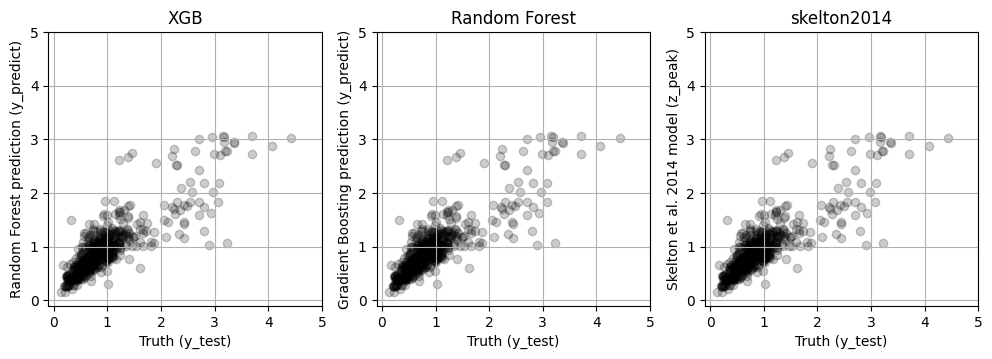

In [28]:
y_predict_xgb = grid_search_xgb.best_estimator_.predict(X_validate)
y_predict_rf = grid_search_rf.best_estimator_.predict(X_validate)
y_skelton2014 = tab['z_peak'].values[indices_validate]
print(f'Gradient Boosting model performance MSE = {mean_squared_error(y_validate, y_predict_xgb):.4f}')
print(f'Random Forest model performance MSE = {mean_squared_error(y_validate, y_predict_rf):.4f}')
print(f'Skelton 2014 et. al. model performance MSE = {mean_squared_error(y_validate, y_skelton2014):.4f}')

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

plot_truth_v_prediction(ax[0],y_test,y_predict,ylabel='Random Forest prediction (y_predict)')
plot_truth_v_prediction(ax[1],y_test,y_predict,ylabel='Gradient Boosting prediction (y_predict)')
plot_truth_v_prediction(ax[2],y_test,y_predict,ylabel='Skelton et al. 2014 model (z_peak)')
ax[0].set_title('XGB')
ax[1].set_title('Random Forest')
ax[2].set_title('skelton2014');